## Import Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('result/eval_comparison.csv')

## FN Analysis: delta_recall_minority

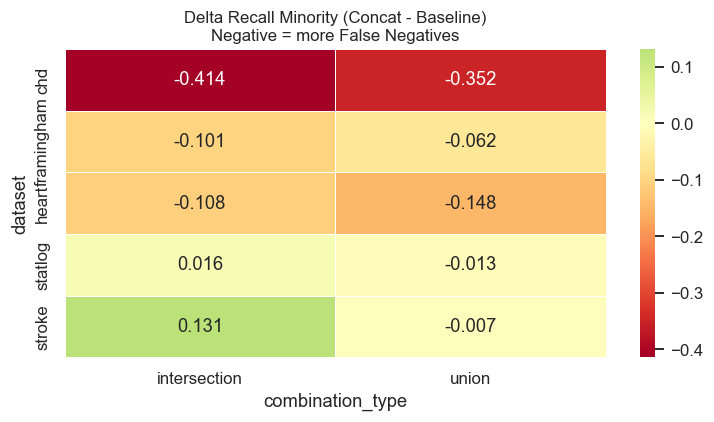

In [2]:
heat_data = (
    df.groupby(['dataset', 'combination_type'])['delta_recall_minority']
    .mean().reset_index()
    .pivot(index='dataset', columns='combination_type', values='delta_recall_minority')
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Delta Recall Minority (Concat - Baseline)\nNegative = more False Negatives', fontsize=11)
plt.tight_layout()
plt.savefig('result/images/error_fn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Pattern: Model x Dataset

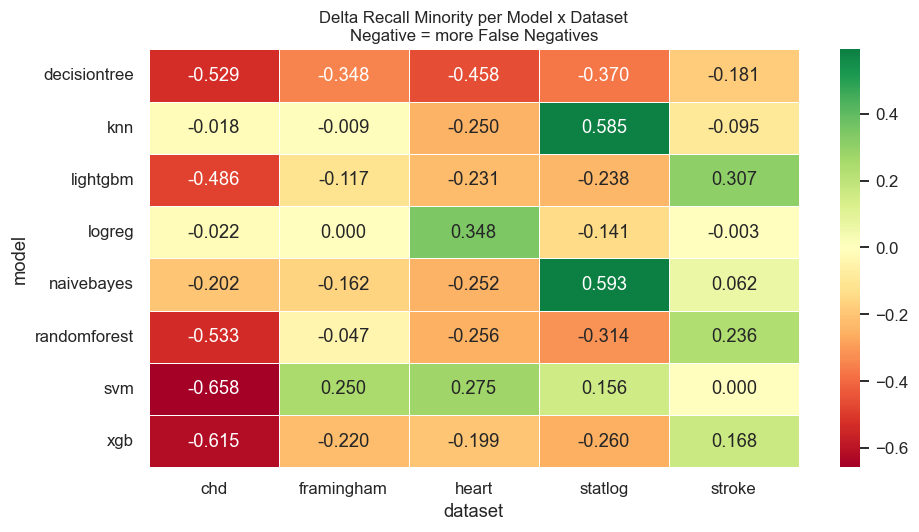

In [3]:
heat_model = (
    df.groupby(['model', 'dataset'])['delta_recall_minority']
    .mean().reset_index()
    .pivot(index='model', columns='dataset', values='delta_recall_minority')
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heat_model, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Delta Recall Minority per Model x Dataset\nNegative = more False Negatives', fontsize=11)
plt.tight_layout()
plt.savefig('result/images/error_fn_model_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary: Cases Where Concat Made Things Worse

In [4]:
df['both_worse'] = (df['delta_f1_macro'] < 0) & (df['delta_recall_minority'] < 0)

summary = (
    df.groupby(['dataset', 'combination_type'])
    .agg(
        mean_delta_f1=('delta_f1_macro', 'mean'),
        mean_delta_recall=('delta_recall_minority', 'mean'),
        pct_both_worse=('both_worse', 'mean')
    )
    .round(3)
    .reset_index()
)

summary

,dataset,combination_type,mean_delta_f1,mean_delta_recall,pct_both_worse
0,chd,intersection,0.059,-0.414,0.062
1,chd,union,0.068,-0.352,0.062
2,framingham,intersection,-0.011,-0.101,0.125
3,framingham,union,0.000,-0.062,0.250
4,heart,intersection,-0.243,-0.108,0.562
5,heart,union,-0.163,-0.148,0.500
6,statlog,intersection,-0.110,0.016,0.375
7,statlog,union,-0.021,-0.013,0.438
8,stroke,intersection,-0.054,0.131,0.000
9,stroke,union,0.007,-0.007,0.125


## Export

In [5]:
summary.to_csv('result/error_analysis.csv', index=False)